# Análise de Resultados dos Modelos Preditivos

Este notebook realiza uma análise comparativa detalhada dos experimentos salvos em `model_results_limpo.csv`.

A análise está dividida nas seguintes etapas:
1. **Importação e Saneamento dos Dados**: Correção da formatação numérica corrompida.
2. **Análise por Modelo**: Comparação da performance geral de cada algoritmo.
3. **Análise por Cenário de Dataset**: Comparação de como as diferentes abordagens de feature engineering impactam os resultados.
4. **Tabela de Escala de Cores (Ranking Geral)**: Visualização dos melhores e piores experimentos utilizando formatação condicional.
5. **Seleção do Melhor Modelo**: Identificação da melhor configuração geral, priorizando o **F1-Score** conforme a regra de negócio.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 1. Importação e Saneamento dos Dados

Os dados salvos no arquivo `model_results_limpo.csv` possuem um problema de formatação regional que inseriu pontos extras nos valores numéricos. Criamos uma função de limpeza para padronizar esses valores entre 0 e 1.

In [93]:
def clean_metric(val):
    if pd.isna(val) or str(val).strip() == "":
        return np.nan
    val_str = str(val).strip()
    # Extrai apenas os dígitos
    digits = "".join([c for c in val_str if c.isdigit()])
    if not digits:
        return np.nan
    # Converte em float com base decimal 0.xxxx
    return float("0." + digits)

# Carregamento do arquivo
columns = [
    "model", "scenario", "smote", "phase", 
    "roc_auc", "f1", "accuracy", "best_params", "timestamp"
]

df = pd.read_csv("model_results_limpo.csv", names=columns, header=None)

# Aplicando a limpeza nas colunas de métricas
for col in ["roc_auc", "f1", "accuracy"]:
    df[col] = df[col].apply(clean_metric)

# Filtrar apenas os resultados de teste para a comparação final de performance
df_test = df[df["phase"] == "test"].copy()
df_test.reset_index(drop=True, inplace=True)

# Exibir uma amostra
df_test.head()

,model,scenario,smote,phase,roc_auc,f1,accuracy,best_params,timestamp
0,DecisionTree,sem_submodalidade,True,test,0.903544,0.837741,0.818014,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-06-06 15:02:31.158004
1,DecisionTree,sem_submodalidade,False,test,0.907223,0.852168,0.827688,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-06-06 15:02:32.173351
2,DecisionTree,submodalidade_agrupada,True,test,0.914931,0.853390,0.831721,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-06-06 15:19:41.101726
3,DecisionTree,submodalidade_agrupada,False,test,0.921325,0.869026,0.843895,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-06-06 15:19:42.404265
4,DecisionTree,submodalidade_engineered,True,test,0.914097,0.842608,0.823818,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-06-06 15:34:53.161090


## 2. Análise por Modelo

Vamos analisar a performance média de cada algoritmo no conjunto de teste.

Performance Média por Modelo (Ordenado por F1-Score Descendente):


,f1,roc_auc,accuracy
model,,,
RandomForest,0.879040,0.937037,0.860251
XGBoost,0.868194,0.933344,0.852072
DecisionTree,0.853423,0.913628,0.831262
LogisticRegression,0.762085,0.800216,0.726906
SVM,0.758329,0.791979,0.721123
KNN,0.728872,0.736594,0.682476


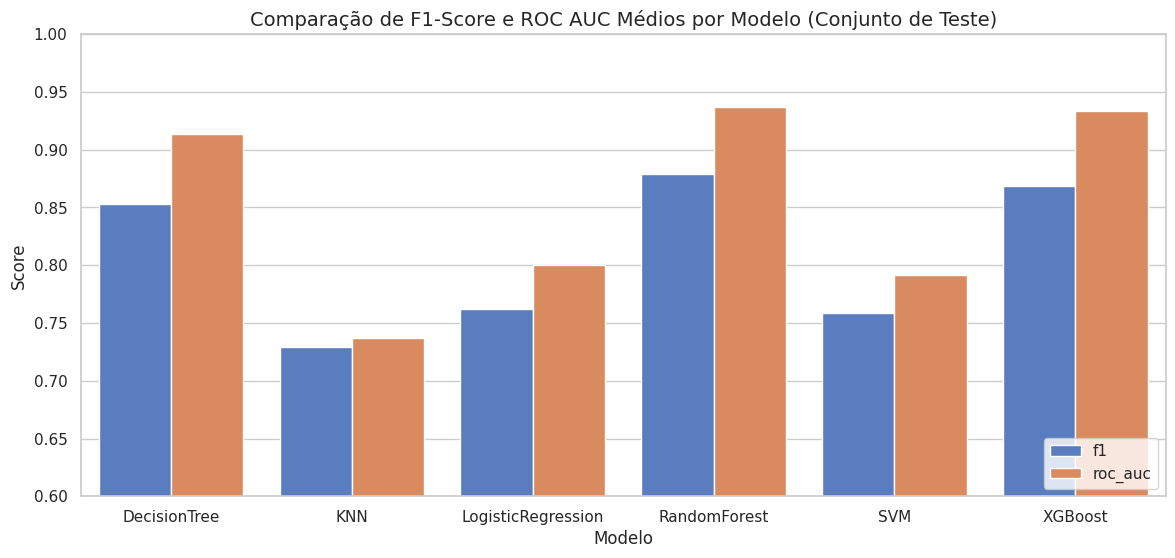

In [94]:
model_summary = df_test.groupby("model")[["f1", "roc_auc", "accuracy"]].mean().sort_values(by="f1", ascending=False)
print("Performance Média por Modelo (Ordenado por F1-Score Descendente):")
display(model_summary.style.background_gradient(cmap="viridis", axis=0))

# Gráfico de barras comparando F1 e ROC AUC
df_melted = df_test.melt(id_vars=["model"], value_vars=["f1", "roc_auc"], var_name="Métrica", value_name="Valor")

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x="model", y="Valor", hue="Métrica", errorbar=None, palette="muted")
plt.title("Comparação de F1-Score e ROC AUC Médios por Modelo (Conjunto de Teste)")
plt.ylim(0.6, 1.0)
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.show()

## 3. Análise por Tipo de Dataset (Cenário)

Abaixo, avaliamos como cada um dos três cenários de pré-processamento de dados se comportou:

Performance Média por Cenário de Dataset:


,f1,roc_auc,accuracy
scenario,,,
submodalidade_agrupada,0.822880,0.869687,0.794027
submodalidade_engineered,0.803889,0.850365,0.775301
sem_submodalidade,0.798202,0.836346,0.767716


/tmp/ipykernel_7829/3960049353.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_test, x="scenario", y="f1", palette="Set2")


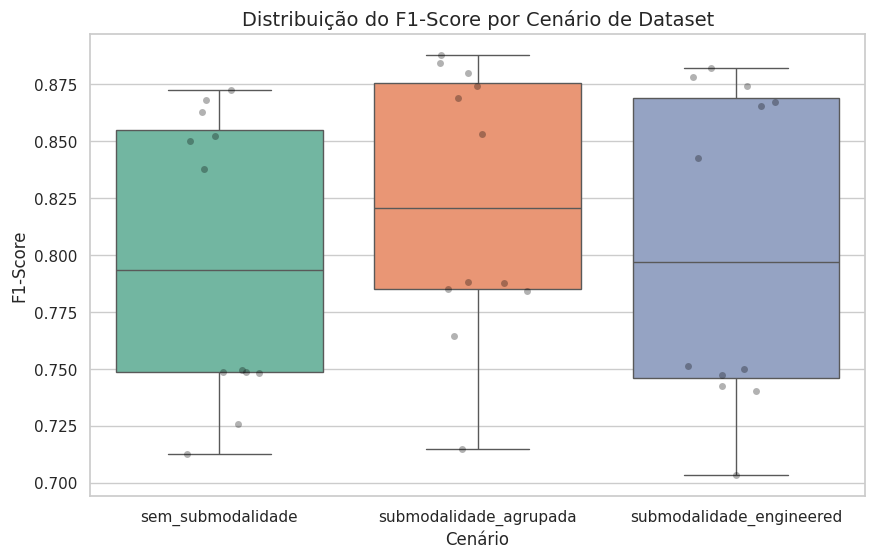

In [95]:
scenario_summary = df_test.groupby("scenario")[["f1", "roc_auc", "accuracy"]].mean().sort_values(by="f1", ascending=False)
print("Performance Média por Cenário de Dataset:")
display(scenario_summary.style.background_gradient(cmap="coolwarm", axis=0))

# Boxplot para visualizar a distribuição dos F1-scores em cada cenário
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_test, x="scenario", y="f1", palette="Set2")
sns.stripplot(data=df_test, x="scenario", y="f1", color="black", alpha=0.3, jitter=0.2)
plt.title("Distribuição do F1-Score por Cenário de Dataset")
plt.xlabel("Cenário")
plt.ylabel("F1-Score")
plt.show()

## 4. Tabela de Escala de Cores (Ranking Geral)

Apresentamos a tabela completa contendo todas as configurações testadas no conjunto de teste, ordenada do melhor para o pior F1-score.

In [96]:
# Ordenando o dataframe de teste completo pelo F1-score
ranking_geral = df_test[["model", "scenario", "smote", "f1", "roc_auc", "accuracy"]].sort_values(by="f1", ascending=False).reset_index(drop=True)

# Aplicando escala de cor para diferenciar melhores (verde/azul) e piores (vermelho)
print("Ranking Geral de Experimentos (Ordenado por F1-Score):")
display(ranking_geral.style.background_gradient(cmap="RdYlGn", subset=["f1", "roc_auc", "accuracy"]))


Ranking Geral de Experimentos (Ordenado por F1-Score):


,model,scenario,smote,f1,roc_auc,accuracy
0,RandomForest,submodalidade_agrupada,False,0.887914,0.944419,0.869447
1,RandomForest,submodalidade_agrupada,True,0.884559,0.943229,0.867202
2,RandomForest,submodalidade_engineered,False,0.882359,0.939863,0.863059
3,XGBoost,submodalidade_agrupada,False,0.880017,0.943110,0.864191
4,RandomForest,submodalidade_engineered,True,0.878402,0.938458,0.860376
5,XGBoost,submodalidade_engineered,False,0.874469,0.937984,0.858168
6,XGBoost,submodalidade_agrupada,True,0.874153,0.939418,0.858952
7,RandomForest,sem_submodalidade,False,0.872629,0.928845,0.851944
8,DecisionTree,submodalidade_agrupada,False,0.869026,0.921325,0.843895
9,RandomForest,sem_submodalidade,True,0.868379,0.927406,0.849480


## 5. Análise do Melhor Modelo Overall

Como definido nas regras de negócio do problema, o critério principal de escolha do melhor modelo é o **F1-Score** (e não o ROC AUC), devido ao equilíbrio necessário entre precisão e sensibilidade nas previsões.

In [97]:
best_experiment = df_test.sort_values(by="f1", ascending=False).iloc[0]

print("=========================================================")
print("🏆 O MELHOR MODELO ENCONTRADO:")
print("=========================================================")
print(f"Modelo:            {best_experiment['model']}")
print(f"Cenário:           {best_experiment['scenario']}")
print(f"Usa SMOTE:         {best_experiment['smote']}")
print(f"F1-Score (Teste):  {best_experiment['f1']:.6f}")
print(f"ROC AUC (Teste):   {best_experiment['roc_auc']:.6f}")
print(f"Acurácia (Teste):  {best_experiment['accuracy']:.6f}")
print(f"Hiperparâmetros:   {best_experiment['best_params']}")
print("=========================================================")

🏆 O MELHOR MODELO ENCONTRADO:
Modelo:            RandomForest
Cenário:           submodalidade_agrupada
Usa SMOTE:         False
F1-Score (Teste):  0.887914
ROC AUC (Teste):   0.944419
Acurácia (Teste):  0.869447
Hiperparâmetros:   {'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200, 'smote': 'passthrough'}


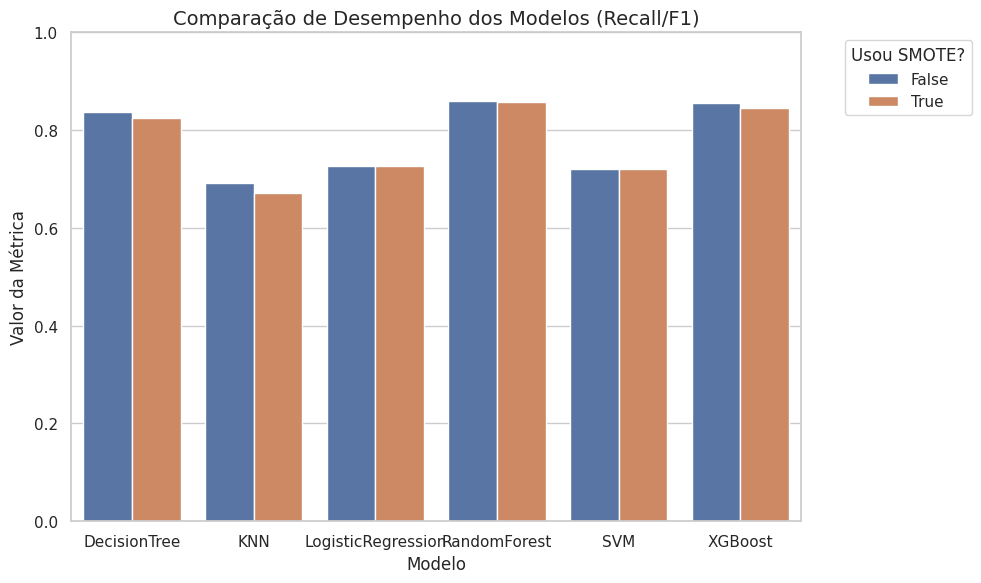

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os resultados
colunas = ['Modelo', 'Cenario', 'Usou_SMOTE', 'Fase', 'Acuracia', 'Precisao', 'Recall_F1', 'Parametros', 'Data']
df_resultados = pd.read_csv('model_results.csv', sep=';', names=colunas)

# Limpar linhas nulas ou vazias
df_resultados = df_resultados.dropna(subset=['Fase'])

# Filtrar apenas as linhas da fase de 'test'
df_teste = df_resultados[df_resultados['Fase'] == 'test'].copy()

# Garantir que as métricas sejam do tipo float
for col in ['Acuracia', 'Precisao', 'Recall_F1']:
    df_teste[col] = pd.to_numeric(df_teste[col], errors='coerce')

# Criar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_teste, x='Modelo', y='Recall_F1', hue='Usou_SMOTE', errorbar=None)
plt.title('Comparação de Desempenho dos Modelos (Recall/F1)')
plt.ylabel('Valor da Métrica')
plt.xlabel('Modelo')
plt.ylim(0, 1.0)
plt.legend(title='Usou SMOTE?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import sys
sys.path.append('..')
from preprocessing.main_preprocessing import load_and_preprocess

# 1. Carregar os dados apenas 1 vez para o melhor cenário
print("Carregando e pre-processando os dados...")
X_train, X_test, y_train, y_test = load_and_preprocess('../predictive_models/scrdata_202505.csv', 'submodalidade_agrupada', use_smote=False)

# 2. Instanciar os modelos com os melhores parâmetros do CSV
modelos = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=4, min_samples_split=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=1, min_samples_split=5, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1, colsample_bytree=1, subsample=0.8, random_state=42, n_jobs=-1),
    "Regressão Logística": LogisticRegression(C=10, solver='lbfgs', random_state=42, max_iter=1000),
    "SVM": SVC(C=10, probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=9, metric='manhattan', weights='uniform', n_jobs=-1)
}

# 3. Treinar os modelos e plotar a Curva ROC TODAS JUNTAS no mesmo gráfico!
print("Iniciando o treinamento dos modelos para gerar o gráfico...")

fig, ax = plt.subplots(figsize=(10, 8))

for nome, modelo in modelos.items():
    print(f"Treinando {nome}...")
    modelo.fit(X_train, y_train)
    
    # O scikit-learn já faz o predict e desenha a curva automaticamente
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=nome)

plt.title("Comparação da Curva ROC entre os Modelos", fontsize=14)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório (Baseline)')
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Processo finalizado!")

,model,scenario,smote,f1,roc_auc,accuracy
Posição,,,,,,
1,RandomForest,submodalidade_agrupada,False,0.887914,0.944419,0.869447
2,RandomForest,submodalidade_agrupada,True,0.884559,0.943229,0.867202
3,RandomForest,submodalidade_engineered,False,0.882359,0.939863,0.863059
4,XGBoost,submodalidade_agrupada,False,0.880017,0.943110,0.864191
5,RandomForest,submodalidade_engineered,True,0.878402,0.938458,0.860376
6,XGBoost,submodalidade_engineered,False,0.874469,0.937984,0.858168
7,XGBoost,submodalidade_agrupada,True,0.874153,0.939418,0.858952
8,RandomForest,sem_submodalidade,False,0.872629,0.928845,0.851944
9,DecisionTree,submodalidade_agrupada,False,0.869026,0.921325,0.843895


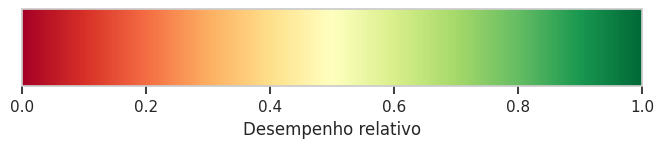

In [100]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 1))

cmap = plt.get_cmap("RdYlGn")
norm = mcolors.Normalize(vmin=0, vmax=1)

cb = plt.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation="horizontal"
)

cb.set_label("Desempenho relativo")
plt.savefig("legenda_cores.png", dpi=300, bbox_inches="tight")

top10 = (
    df_test[["model", "scenario", "smote", "f1", "roc_auc", "accuracy"]]
    .sort_values(by="f1", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10.index = top10.index + 1
top10.index.name = "Posição"

display(
    top10.style.background_gradient(
        cmap="RdYlGn",
        subset=["f1", "roc_auc", "accuracy"]
    )
)